# Prévision de pluie en Australie — 3/3 · Modélisation & évaluation

**Cette partie** : Régression Logistique, Random Forest (+ variante `balanced`), comparatif vs baselines, conclusions & pistes MLOps.

> **Notebook indépendant** — il recharge les données depuis zéro (chaque partie s'exécute seule). Voir aussi : `01_exploration.ipynb`, `02_preprocessing.ipynb`, `03_modelisation.ipynb`.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)
RANDOM_STATE = 42

/home/tinkerbell/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# Résolution robuste du chemin des données : fonctionne que le notebook soit
# lancé depuis la racine du projet ou depuis le dossier notebooks/.
CANDIDATES = [
    Path("Data/weatherAUS.csv"),
    Path("../Data/weatherAUS.csv"),
    Path.home() / "Desktop/MlOps_Meteo-Liora/Data/weatherAUS.csv",
]
DATA_PATH = next((p for p in CANDIDATES if p.exists()), None)
assert DATA_PATH is not None, "weatherAUS.csv introuvable (vérifier le dossier Data/)"

df = pd.read_csv(DATA_PATH, na_values=["NA"])
print(f"Chargé depuis : {DATA_PATH}")
print(f"Dimensions    : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
df.head()

Chargé depuis : ../Data/weatherAUS.csv
Dimensions    : 145,460 lignes × 23 colonnes


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


### Rappel — préprocessing
On reconstruit ici le pipeline de préparation (détaillé dans `02_preprocessing.ipynb`) pour que ce notebook soit exécutable seul.

In [3]:
data = df.drop(columns=["_month"], errors="ignore").copy()
data = data.dropna(subset=["RainTomorrow"]).copy()

# Cible 0/1
y = (data["RainTomorrow"] == "Yes").astype(int)

# Feature temporelle
data["Month"] = pd.to_datetime(data["Date"], errors="coerce").dt.month.astype("Int64")
data = data.drop(columns=["Date", "RainTomorrow"])

# Listes de features
categorical_features = ["Location", "WindGustDir", "WindDir9am", "WindDir3pm", "RainToday", "Month"]
numeric_features = [c for c in data.columns if c not in categorical_features]
X = data

print(f"Échantillons : {len(X):,}  |  numériques : {len(numeric_features)}  |  catégorielles : {len(categorical_features)}")
print("Numériques  :", numeric_features)
print("Catégoriques:", categorical_features)

Échantillons : 142,193  |  numériques : 16  |  catégorielles : 6
Numériques  : ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']
Catégoriques: ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'Month']


In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features),
])
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## 3. Modélisation

Deux modèles classiques pour la classification binaire — **Régression Logistique** (référence linéaire)
et **Random Forest** (ensemble non linéaire) — chacun encapsulé dans un pipeline avec le préprocesseur,
donc **ajusté uniquement sur le train**. Métriques : accuracy, *recall*/F1 de la classe « pluie », ROC-AUC.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, recall_score, f1_score)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print(f"Train : {X_train.shape[0]:,}  |  Test : {X_test.shape[0]:,}")

Train : 113,754  |  Test : 28,439


### 3.1 Régression Logistique

Accuracy : 0.8494   ROC-AUC : 0.8730
              precision    recall  f1-score   support

          No       0.87      0.95      0.91     22064
         Yes       0.73      0.52      0.61      6375

    accuracy                           0.85     28439
   macro avg       0.80      0.73      0.76     28439
weighted avg       0.84      0.85      0.84     28439



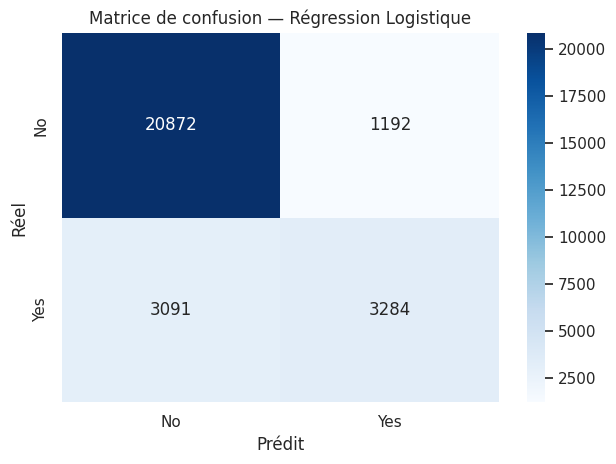

In [6]:
pipe_lr = Pipeline([("prep", preprocessor),
                    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)
proba_lr = pipe_lr.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}   ROC-AUC : {roc_auc_score(y_test, proba_lr):.4f}")
print(classification_report(y_test, y_pred_lr, target_names=["No", "Yes"]))

cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
plt.title("Matrice de confusion — Régression Logistique")
plt.xlabel("Prédit"); plt.ylabel("Réel"); plt.tight_layout(); plt.show()

**Lecture.** Bonne accuracy globale (~0,85), mais le *recall* sur la classe « pluie » reste
modeste (~0,5) : le modèle rate environ la moitié des jours de pluie — conséquence directe du
déséquilibre. La ROC-AUC (~0,87) montre tout de même un bon pouvoir discriminant.

### 3.2 Random Forest

Accuracy : 0.8561   ROC-AUC : 0.8887
              precision    recall  f1-score   support

          No       0.87      0.96      0.91     22064
         Yes       0.78      0.50      0.61      6375

    accuracy                           0.86     28439
   macro avg       0.83      0.73      0.76     28439
weighted avg       0.85      0.86      0.84     28439



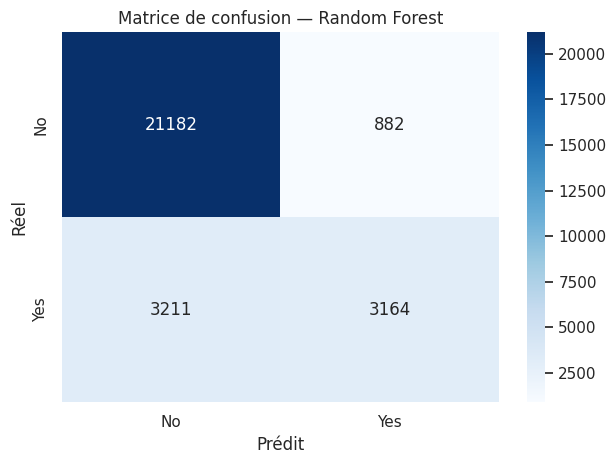

In [7]:
pipe_rf = Pipeline([("prep", preprocessor),
                    ("clf", RandomForestClassifier(n_estimators=100, n_jobs=-1,
                                                   random_state=RANDOM_STATE))])
pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)
proba_rf = pipe_rf.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}   ROC-AUC : {roc_auc_score(y_test, proba_rf):.4f}")
print(classification_report(y_test, y_pred_rf, target_names=["No", "Yes"]))

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
plt.title("Matrice de confusion — Random Forest")
plt.xlabel("Prédit"); plt.ylabel("Réel"); plt.tight_layout(); plt.show()

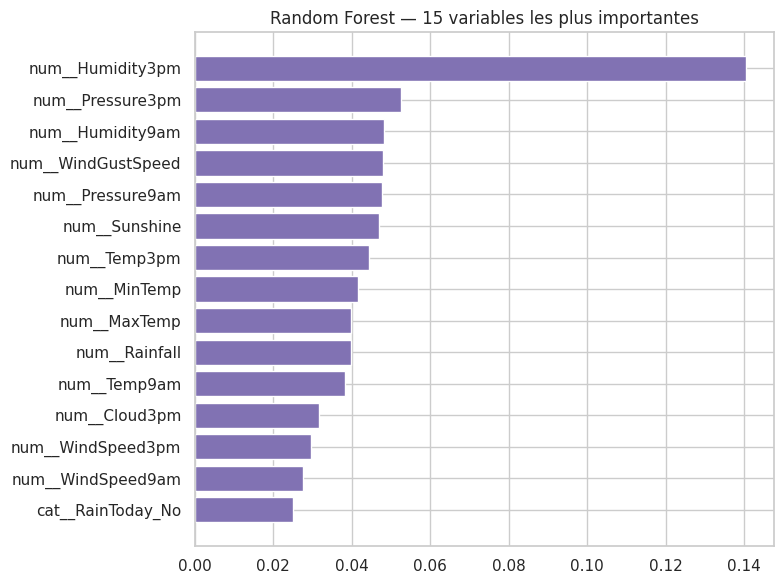

num__Humidity3pm      0.1406
num__Pressure3pm      0.0525
num__Humidity9am      0.0482
num__WindGustSpeed    0.0479
num__Pressure9am      0.0478
num__Sunshine         0.0469
num__Temp3pm          0.0443
num__MinTemp          0.0416
num__MaxTemp          0.0400
num__Rainfall         0.0399
num__Temp9am          0.0383
num__Cloud3pm         0.0317
num__WindSpeed3pm     0.0297
num__WindSpeed9am     0.0275
cat__RainToday_No     0.0250
dtype: float64

In [8]:
# Importance des variables (top 15)
feat_names = pipe_rf.named_steps["prep"].get_feature_names_out()
importances = pd.Series(pipe_rf.named_steps["clf"].feature_importances_, index=feat_names)
top15 = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top15.index[::-1], top15.values[::-1], color="#8172B3")
ax.set_title("Random Forest — 15 variables les plus importantes")
plt.tight_layout(); plt.show()
top15.round(4)

**Lecture.** Le Random Forest fait légèrement mieux (accuracy ~0,855, ROC-AUC ~0,88) mais
souffre du **même recall faible** sur la classe « pluie ». Les variables dominantes confirment l'EDA :
`Humidity3pm`, `Sunshine`, `Pressure`, `Rainfall`, `WindGustSpeed`.

### 3.3 Comparatif — modèles vs baselines

Bonus : une régression logistique `class_weight="balanced"` pour illustrer l'effet de la prise en
compte du déséquilibre (recall « pluie » ↑ au prix de l'accuracy globale ↓).

In [9]:
pipe_lr_bal = Pipeline([("prep", preprocessor),
                        ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                                                   class_weight="balanced"))])
pipe_lr_bal.fit(X_train, y_train)
y_pred_bal = pipe_lr_bal.predict(X_test)
proba_bal = pipe_lr_bal.predict_proba(X_test)[:, 1]

def row(name, y_pred, proba=None):
    return {
        "Modèle": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Recall (pluie)": round(recall_score(y_test, y_pred), 4),
        "F1 (pluie)": round(f1_score(y_test, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_test, proba), 4) if proba is not None else np.nan,
    }

# baseline "toujours Non" sur le test
y_pred_zero = np.zeros_like(y_test)

compare = pd.DataFrame([
    row("Baseline toujours-Non", y_pred_zero),
    row("Régression Logistique", y_pred_lr, proba_lr),
    row("Random Forest", y_pred_rf, proba_rf),
    row("Rég. Log. (balanced)", y_pred_bal, proba_bal),
]).set_index("Modèle")
compare

,Accuracy,Recall (pluie),F1 (pluie),ROC-AUC
Modèle,,,,
Baseline toujours-Non,0.7758,0.0000,0.0000,NaN
Régression Logistique,0.8494,0.5151,0.6053,0.8730
Random Forest,0.8561,0.4963,0.6072,0.8887
Rég. Log. (balanced),0.7955,0.7795,0.6309,0.8737


## 4. Conclusions & pistes MLOps

**Synthèse data.**
- Dataset propre dans l'ensemble (0 doublon), ~145 k lignes / 49 stations / ~10 ans.
- Cible **déséquilibrée** (~22 % de pluie) ⇒ piloter sur recall/F1 de la classe « pluie », pas l'accuracy.
- Prédicteurs clés cohérents physiquement : `Sunshine`, `Humidity3pm`, `Cloud3pm`, `Pressure`, plus station & saison.
- Les deux modèles atteignent ~0,85 d'accuracy / ~0,87–0,88 de ROC-AUC mais **ratent ~½ des jours de pluie** ;
  `class_weight="balanced"` remonte nettement le recall (au prix de l'accuracy) — arbitrage métier à trancher.

**Améliorations modèle.** gérer le déséquilibre (class weights / SMOTE / ajustement du seuil de décision),
feature engineering temporel (saison cyclique, retards), gestion fine de la forte missingness de `Sunshine`/`Cloud`
(indicateurs de manquant), validation **temporelle** (éviter de prédire le passé avec le futur), tuning (XGBoost/LightGBM).

**Vers le MLOps (roadmap projet).** ce notebook est le brouillon ; les étapes suivantes consistent à :
1. extraire ces traitements en scripts versionnés (`process.py`, `train.py`, `evaluate.py`) ;
2. tracer chaque entraînement avec **MLflow** (params, métriques, artefacts) ;
3. versionner données & modèles (**DVC**) ; 4. exposer une **API d'inférence** ; 5. conteneuriser (Docker Compose).